In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('updated_version.csv')

In [3]:
df

,age,sex,total_cholesterol,ldl,hdl,systolic_bp,diastolic_bp,smoking,diabetes,heart_attack
0,57,1,229.463642,175.879129,39.225687,124.070127,91.378780,0,0,0
1,58,1,186.464120,128.984916,34.950968,95.492552,64.355040,1,0,0
2,37,1,251.300719,152.347592,45.913288,99.519335,64.953147,0,1,0
3,55,1,192.058908,116.803684,67.208925,122.460002,73.821382,0,0,0
4,53,1,151.203448,107.017396,60.693838,123.022257,81.121946,0,1,0
...,...,...,...,...,...,...,...,...,...,...
995,65,1,195.336429,149.070951,43.914928,132.878440,86.246414,0,0,0
996,60,1,192.342928,134.357395,53.380714,145.149535,91.069141,0,0,0
997,70,0,174.179319,125.900047,50.406918,133.022878,85.851330,0,0,0
998,48,0,189.715685,152.388737,40.700912,113.527965,86.368294,0,0,0


In [4]:
df.shape

(1000, 10)

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1000 non-null   int64  
 1   sex                1000 non-null   int64  
 2   total_cholesterol  1000 non-null   float64
 3   ldl                1000 non-null   float64
 4   hdl                1000 non-null   float64
 5   systolic_bp        1000 non-null   float64
 6   diastolic_bp       1000 non-null   float64
 7   smoking            1000 non-null   int64  
 8   diabetes           1000 non-null   int64  
 9   heart_attack       1000 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 78.3 KB


,age,sex,total_cholesterol,ldl,hdl,systolic_bp,diastolic_bp,smoking,diabetes,heart_attack
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.886000,0.52700,201.087486,130.047807,49.811244,120.312687,80.231248,0.202000,0.090000,0.104000
std,14.209466,0.49952,40.042655,30.041659,10.247178,15.507493,10.235917,0.401693,0.286325,0.305413
min,18.000000,0.00000,84.165932,36.259745,20.600644,74.433950,49.296305,0.000000,0.000000,0.000000
25%,40.000000,0.00000,174.707208,111.963197,42.622102,110.062952,73.277119,0.000000,0.000000,0.000000
50%,49.000000,1.00000,201.191547,130.678540,49.682809,120.042175,79.912592,0.000000,0.000000,0.000000
75%,59.000000,1.00000,226.251708,149.732446,56.703598,130.911804,87.084443,0.000000,0.000000,0.000000
max,94.000000,1.00000,354.660015,231.376631,82.319810,164.080967,113.848127,1.000000,1.000000,1.000000


In [6]:
df.head(2)

,age,sex,total_cholesterol,ldl,hdl,systolic_bp,diastolic_bp,smoking,diabetes,heart_attack
0,57,1,229.463642,175.879129,39.225687,124.070127,91.37878,0,0,0
1,58,1,186.464120,128.984916,34.950968,95.492552,64.35504,1,0,0


In [7]:
df['smoking'].value_counts()

smoking
0    798
1    202
Name: count, dtype: int64

In [8]:
df['diabetes'].value_counts()

diabetes
0    910
1     90
Name: count, dtype: int64

In [9]:
df['heart_attack'].value_counts()

heart_attack
0    896
1    104
Name: count, dtype: int64

In [10]:
df.isnull().sum()

age                  0
sex                  0
total_cholesterol    0
ldl                  0
hdl                  0
systolic_bp          0
diastolic_bp         0
smoking              0
diabetes             0
heart_attack         0
dtype: int64

EDA

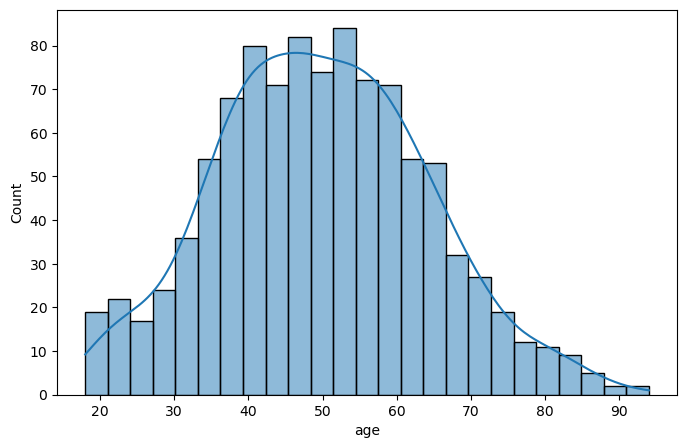

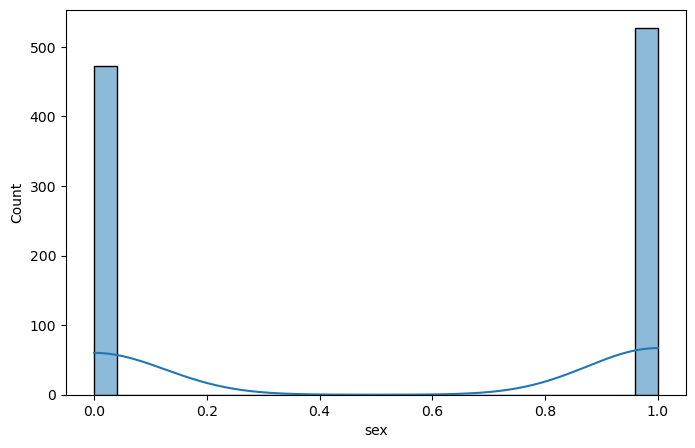

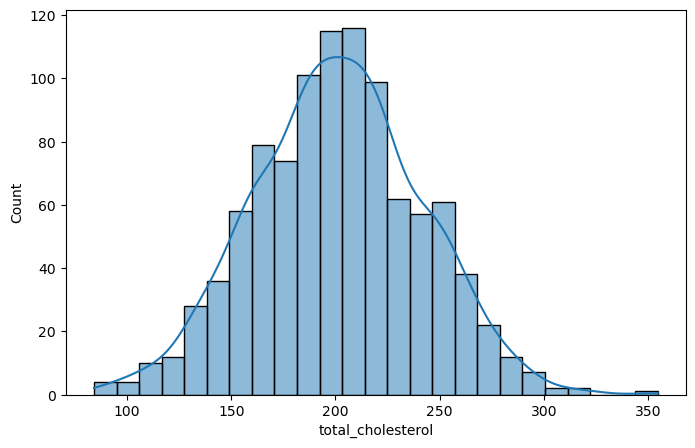

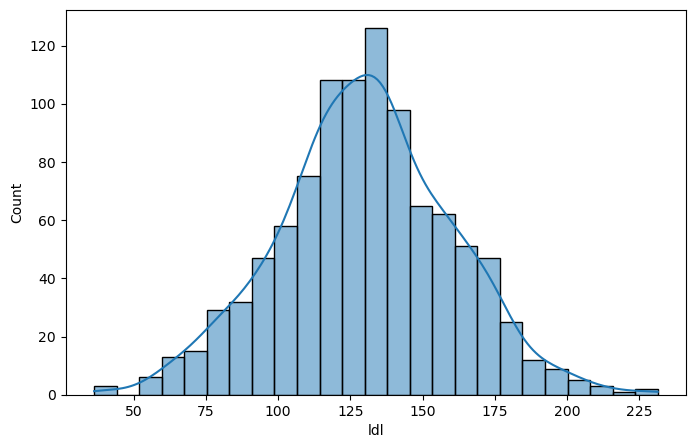

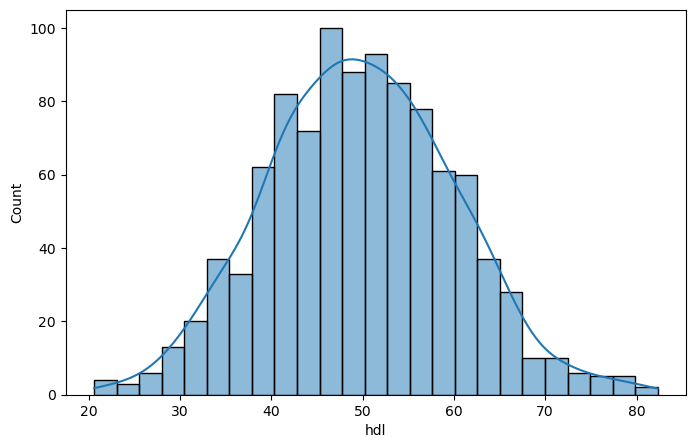

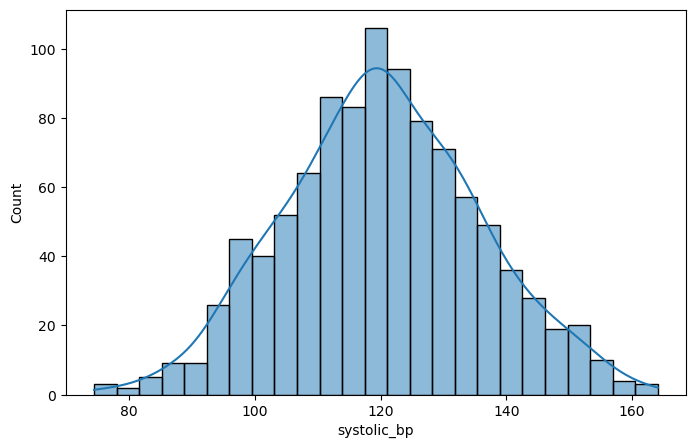

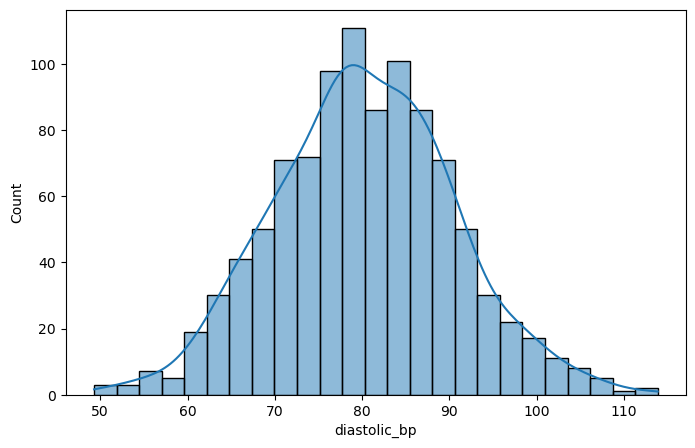

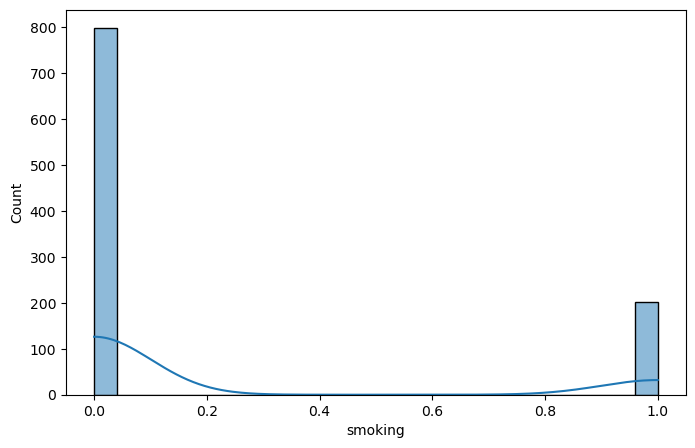

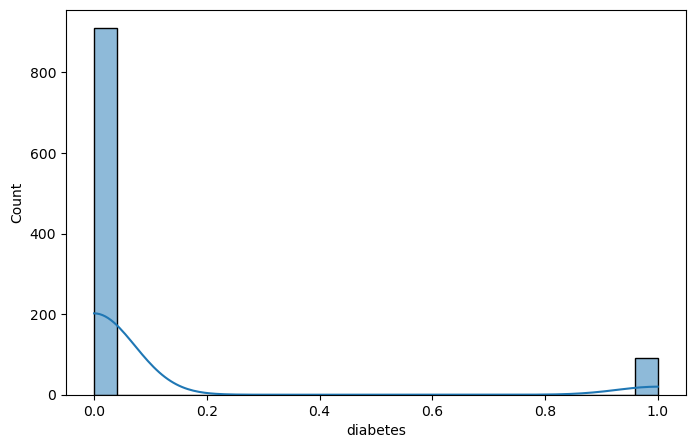

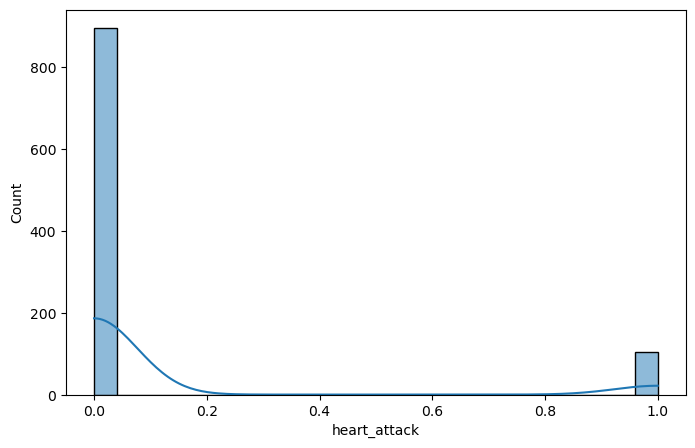

In [11]:
num = df.select_dtypes(include='number')

for n in num:
    plt.figure(figsize=(8,5))
    sns.histplot(df[n] , kde=True , bins=25)

<Axes: >

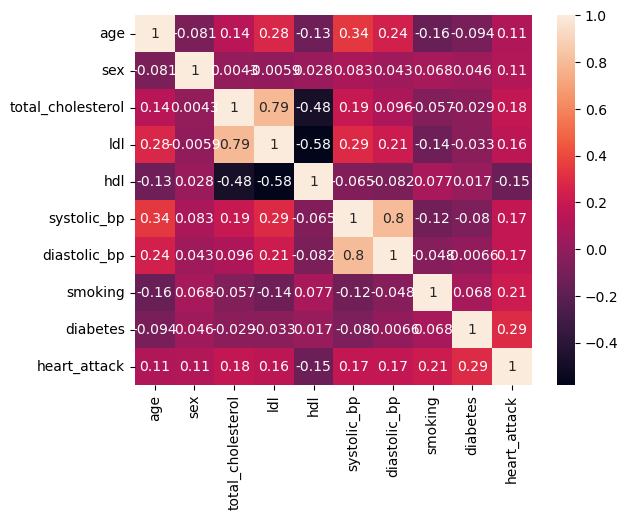

In [12]:
sns.heatmap(num.corr() , annot=True)

In [13]:
col_to_drop = ['diastolic_bp' , 'total_cholesterol']
df_clean = df.drop(columns=col_to_drop)

In [14]:
df_clean

,age,sex,ldl,hdl,systolic_bp,smoking,diabetes,heart_attack
0,57,1,175.879129,39.225687,124.070127,0,0,0
1,58,1,128.984916,34.950968,95.492552,1,0,0
2,37,1,152.347592,45.913288,99.519335,0,1,0
3,55,1,116.803684,67.208925,122.460002,0,0,0
4,53,1,107.017396,60.693838,123.022257,0,1,0
...,...,...,...,...,...,...,...,...
995,65,1,149.070951,43.914928,132.878440,0,0,0
996,60,1,134.357395,53.380714,145.149535,0,0,0
997,70,0,125.900047,50.406918,133.022878,0,0,0
998,48,0,152.388737,40.700912,113.527965,0,0,0


In [15]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

In [16]:
x = df_clean.drop(columns=['heart_attack'])
y = df_clean['heart_attack']

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42 , stratify=y)

#smote
sm = SMOTE(random_state=42)
x_train_sm , y_train_sm = sm.fit_resample(x_train , y_train)

#scaler
scaler = StandardScaler()
x_train_sm = scaler.fit_transform(x_train_sm)
x_test = scaler.transform(x_test)


In [28]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [51]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(max_depth= None, n_estimators=500, min_samples_split=2 , min_samples_leaf=2 , max_features='sqrt' , random_state=42),
     'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(learning_rate=0.2, max_depth=7 , n_estimators=200 ,random_state=42 , subsample=0.9)
}

In [45]:
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), 
                       gb_params, cv=5, scoring='accuracy', n_jobs=-1)
gb_grid.fit(x_train_sm, y_train_sm)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 0.9, 1.0]},
             scoring='accuracy')

In [52]:
result = []

for name , model in models.items():
    model.fit(x_train_sm , y_train_sm)
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test , y_pred)

    result.append({
        "name" : name,
        "Acc" : acc
    })
    

In [31]:
print(x_train_sm.shape)
print(y_train_sm.shape)

(1434, 7)
(1434,)


In [53]:
result_df = pd.DataFrame(result).sort_values(by='Acc' , ascending=False)

In [44]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

rf_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), 
                       rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(x_train_sm, y_train_sm)
print("Best RF params:", rf_grid.best_params_)

Best RF params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


In [54]:
result_df

,name,Acc
1,Random Forest,0.795
2,XGBoost,0.780
3,Gradient Boosting,0.775
0,Logistic Regression,0.735


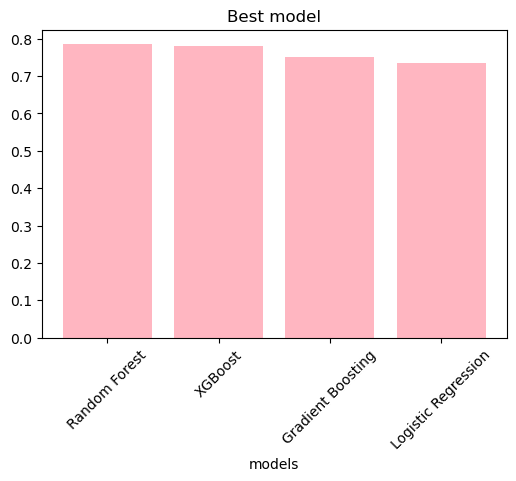

<Figure size 640x480 with 0 Axes>

In [35]:
plt.figure(figsize=(6,4))
plt.bar(result_df['name'] , result_df['Acc'] , color='lightpink')
plt.title('Best model')
plt.xticks(rotation=45)
plt.xlabel('models')
plt.show()
plt.tight_layout()


In [55]:
best_model_name = 'Random Forest'
best_model = models[best_model_name]

In [56]:
import joblib

joblib.dump(best_model , 'heart_Attack_model_R.pkl')

['heart_Attack_model_R.pkl']